# Mini-Project 2
*Kim Concepcion Nielsen*

*Course : Numerical Scientific Computing 2026*

## Hardware Specs
* CPU Model: Quad-Core Intel Core i7
* CPU Cores: 4
* RAM: 16GB
* L2-buffer per core: 256 kB
* L3-buffer: 8 MB

## Operating System Information
* System version: macOS 13.7.8 (22H730)

## Library versions
* Python: 3.11.14

### Python packages (relevant for Mandelbrot / performance)

| Package     | Version |
|------------|--------|
| numpy      | 1.26.4 |
| numba      | 0.63.1 |
| matplotlib | 3.10.8 |
| line_profiler  | 5.0.2  |
| memory_profiler| 0.61.0 |

### Measurement Methodology
All benchmarks in this performance notebook have been carried out with perf_counter() to measure time execution. Additionally, all benchmarks are based on multiple runs to get an average perspective of the results. Some of the Python code in this notebook has been executed directly from a .py file as I have experienced issues running multiprocessing code directly from a Jupyter Notebook cell. Keep in mind, that results might vary depending on what hardware and software versions are used to run the code in this notebook. All relevant applied hardware and software versions have been documented in this notebook.

---

## Multiprocessing

### Monte Carlo π

**Exercise 1: Serial Implementation**

In [6]:
import math, random, time, statistics
import matplotlib.pyplot as plt

def estimate_pi_serial(num_samples):
    hits_inside_circle = 0
    for _ in range(num_samples):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            hits_inside_circle += 1
    return 4 * hits_inside_circle / num_samples

def do_serial():
    num_samples  = 10_000_000
    times        = []
    
    for _ in range(3):
        t0 = time.perf_counter()
        pi_estimate = estimate_pi_serial(num_samples)
        times.append(time.perf_counter() - t0)
    t_serial = statistics.median(times)

    print(f"pi estimate: {pi_estimate:.6f} (error: {abs(pi_estimate-math.pi):.6f})")
    print(f"Serial time: {t_serial:.3f}s")

if __name__ == '__main__':
    do_serial()
    do_serial()
    do_serial()

pi estimate: 3.141061 (error: 0.000531)
Serial time: 1.769s
pi estimate: 3.142204 (error: 0.000611)
Serial time: 1.758s
pi estimate: 3.141259 (error: 0.000333)
Serial time: 1.760s


Questions:
* How accurate is the estimate? Run several times — does it vary? *Yes the serial time varies, but the change is quite small*
* What is the serial time? This will be your speedup denominator in E3. *Serial time lies between 1.758-1.769 seconds*

**Exercise 2: Parallel Implementation**

In [ ]:
from multiprocessing import Pool
import os, random, time, statistics
import matplotlib.pyplot as plt
import psutil

def estimate_pi_chunk(num_samples):
    inside_circle = 0
    for _ in range(num_samples):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            inside_circle += 1
    return inside_circle

def estimate_pi_parallel(num_samples, num_processes=4):
    samples_per_process = num_samples // num_processes
    tasks = [samples_per_process] * num_processes
    with Pool(processes=num_processes) as pool:
        results = pool.map(estimate_pi_chunk, tasks)
    return 4 * sum(results) / num_samples

if __name__ == '__main__':
    cores = psutil.cpu_count(logical=False)
    print(f'Number of cores: {cores}')
    
    num_samples = 10_000_000

    results = []
    for num_proc in range(1, cores + 1):
        times = []
        pi_0_est = 0
        
        for idx in range(3):
            t0 = time.perf_counter()
            pi_est = estimate_pi_parallel(num_samples, num_proc)
            
            t1 = time.perf_counter() - t0
            times.append(t1)
        
        t = statistics.median(times)        
        new_result = {
            'workers' : num_proc,
            'pi' : pi_est,
            't': t,
            'speedup': 0,
            'eff' : 0,
            's' : 0
        }
        
        results.append(new_result)

    # Compute speedups
    t0 = results[0]['t']
    for result in results:
        result['speedup'] = t0 / result['t']
        result['eff']     = result['speedup'] / result['workers']
        
        # avoid division by 0 :-P
        if result['workers'] > 1:
            result['s'] = (1/result['speedup'] - 1/result['workers']) / (1 - 1/result['workers'])
        
        print(f"{result['workers']:2d} workers t={result['t']:.3f}s pi={result['pi']:.6f} sp={result['speedup']:.3f} eff={result['eff']*100.0:.3f}% s={result['s']:.3f}")
    
    # Plotting
    workers   = [ r['workers'] for r in results ]
    times     = [ r['t'] for r in results ]
    speedups  = [ r['speedup'] for r in results ]

    plt.figure()
    plt.plot(workers, times, marker='o', label='Measured execution time vs # of cores')
    plt.xlabel('Workers (# of cores)')
    plt.ylabel('Execution Time [s]')
    plt.title('Execution time vs number of cores')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()
    
    ideal = workers
    plt.figure()
    plt.plot(workers, ideal, 'k--', label='Ideal linear')
    plt.plot(workers, speedups, marker='o', label='Measured speedup vs # of cores')
    plt.xlabel('Workers (# of cores)')
    plt.ylabel('Speedup')
    plt.title('Speedup vs workers')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


```
Number of cores: 4
 1 workers t=1.979s pi=3.141551 sp=1.000 eff=100.000% s=0.000
 2 workers t=1.406s pi=3.141328 sp=1.407 eff=70.373% s=0.421
 3 workers t=1.095s pi=3.140851 sp=1.808 eff=60.257% s=0.330
 4 workers t=1.067s pi=3.141765 sp=1.855 eff=46.364% s=0.386
```

Questions:
* Do all worker counts give the same ˆπ? Why or why not? *No. When each created task executes estimate_pi_chunk() which generates new random x and y points. Because of this the pi values will never be identical*
* At which count do you first see a meaningful speedup? *Based on the execution time results, I would say that the first significant speedup already happens at 2 workers. The biggest speedup seems to be around 4 workers*

**Exercise 3: Analyze Results**

Parallel efficiency: E_p = S_p/p - fraction of ideal speedup per core (100%=perfect).
For each worker count (1 to cpu_count()), tabulate: workers | time (s) | speedup S_p | efficiency E_p (%)

Questions to discuss:
1. At which worker count $p^∗$ is speedup maximum? *Based on the code output above, the biggest speedup seems to be at 4 workers*
2. Does speedup plateau or drop beyond $p^∗$? Why? *From 3 to 4 workers, the speedup does not increase much and almost stays flat. This could be due to a higher portion of time is spent on IPC overhead, which is a sequential process.*
3. Back-solve implied serial fraction: $s=\frac{1/s_{p^*}-1/p^*}{1-1/p^*}$ what fraction of time is effectively serial (IPC overhead + spawning)? *According to the code output the serial fraction for e.g. 4 workers where we have maximum speedup, the serial fraction is 0.3854*

(Optional) Plot: workers (x) vs. speedup (y) — actual and ideal linear.

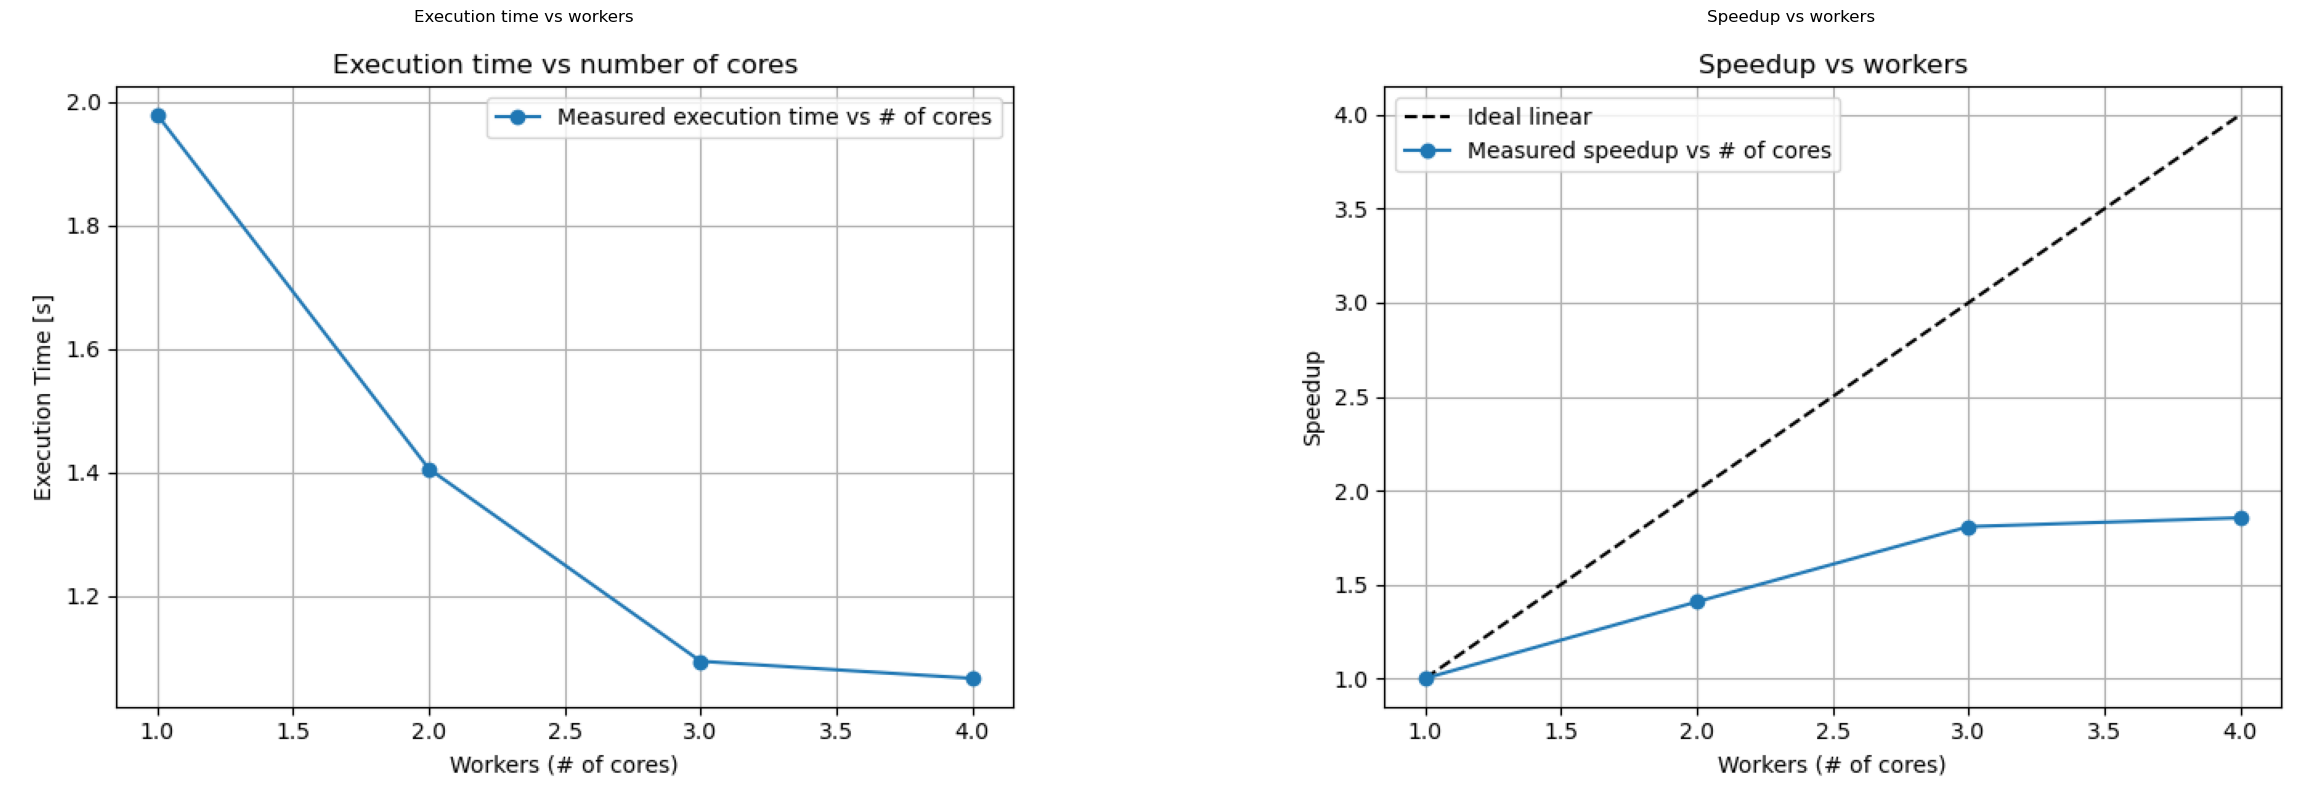

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('execution_time_vs_workers.png')
img2 = mpimg.imread('speedup_vs_workers.png')

fig, ax = plt.subplots( 1,2, figsize=(30,10) )
ax[0].imshow(img1)
ax[0].set_title('Execution time vs workers')
ax[0].axis('off')
ax[1].imshow(img2)
ax[1].set_title('Speedup vs workers')
ax[1].axis('off')

plt.show()

### Parallel Mandelbrot

**M1 Refactor Code**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import statistics
import time

import numpy as np
from numba import njit, prange

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N              = 1024 # Same width & height
x_min          = -2.0 # min point on real axis
x_max          = 1.0  # max point on real axis
y_min          = -1.5 # min point on imaginary axis
y_max          = 1.5  # max point on imaginary axis
max_iteration  = 100 # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------

@njit
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0
    
    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if ( z_real_sq + z_imag_sq ) > 4: return n
        z_imag = 2.0 * z_real*z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty( (row_end - row_start, N), dtype=np.int32)
    dx = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(x_min + column*dx, c_imag, max_iter)
    return mandelbrot_set

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter):
    """
    Calls whole grid as a single chunk
    """
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

def benchmark ( func , * args , n_runs =3) -> tuple:
    """ Time func , return median of n_runs . """
    times = []
    for _ in range ( n_runs ):
        t0 = time . perf_counter ()
        result = func (* args )
        times . append ( time . perf_counter () - t0 )
    
    median_t = statistics . median ( times )
    
    print (f" Median : { median_t :.4f}s "
        f"( min ={ min( times ):.4f}, max ={ max( times ):.4f})")
    
    return median_t, result


if __name__ == '__main__':

    t, M = benchmark(mandelbrot_serial, N, x_min, x_max, y_min, y_max, max_iteration, n_runs=1) # Includes benchmark time to compile functions
    t, M = benchmark(mandelbrot_serial, N, x_min, x_max, y_min, y_max, max_iteration, n_runs=1) # Excludes benchmark time to compile functions

    # Plot Serial Mandelbrot
    from multiprocessing import Pool
    from pathlib import Path

    fig, ax = plt.subplots( figsize=(8,6) )
    im = ax.imshow(M, extent=[x_min, x_max, y_min, y_max], cmap='plasma', origin='lower', aspect='equal')
    fig.colorbar(im, ax=ax)
    ax.set_xlabel('Re(c)')
    ax.set_ylabel('Im(c)')
    out = Path(__file__).parent / 'm1_serial_mandelbrot.png'
    fig.savefig(out, dpi=150)
    print(f'Saved: {out}')

*Serial Mandelbrot vs L03 Mandelbrot*

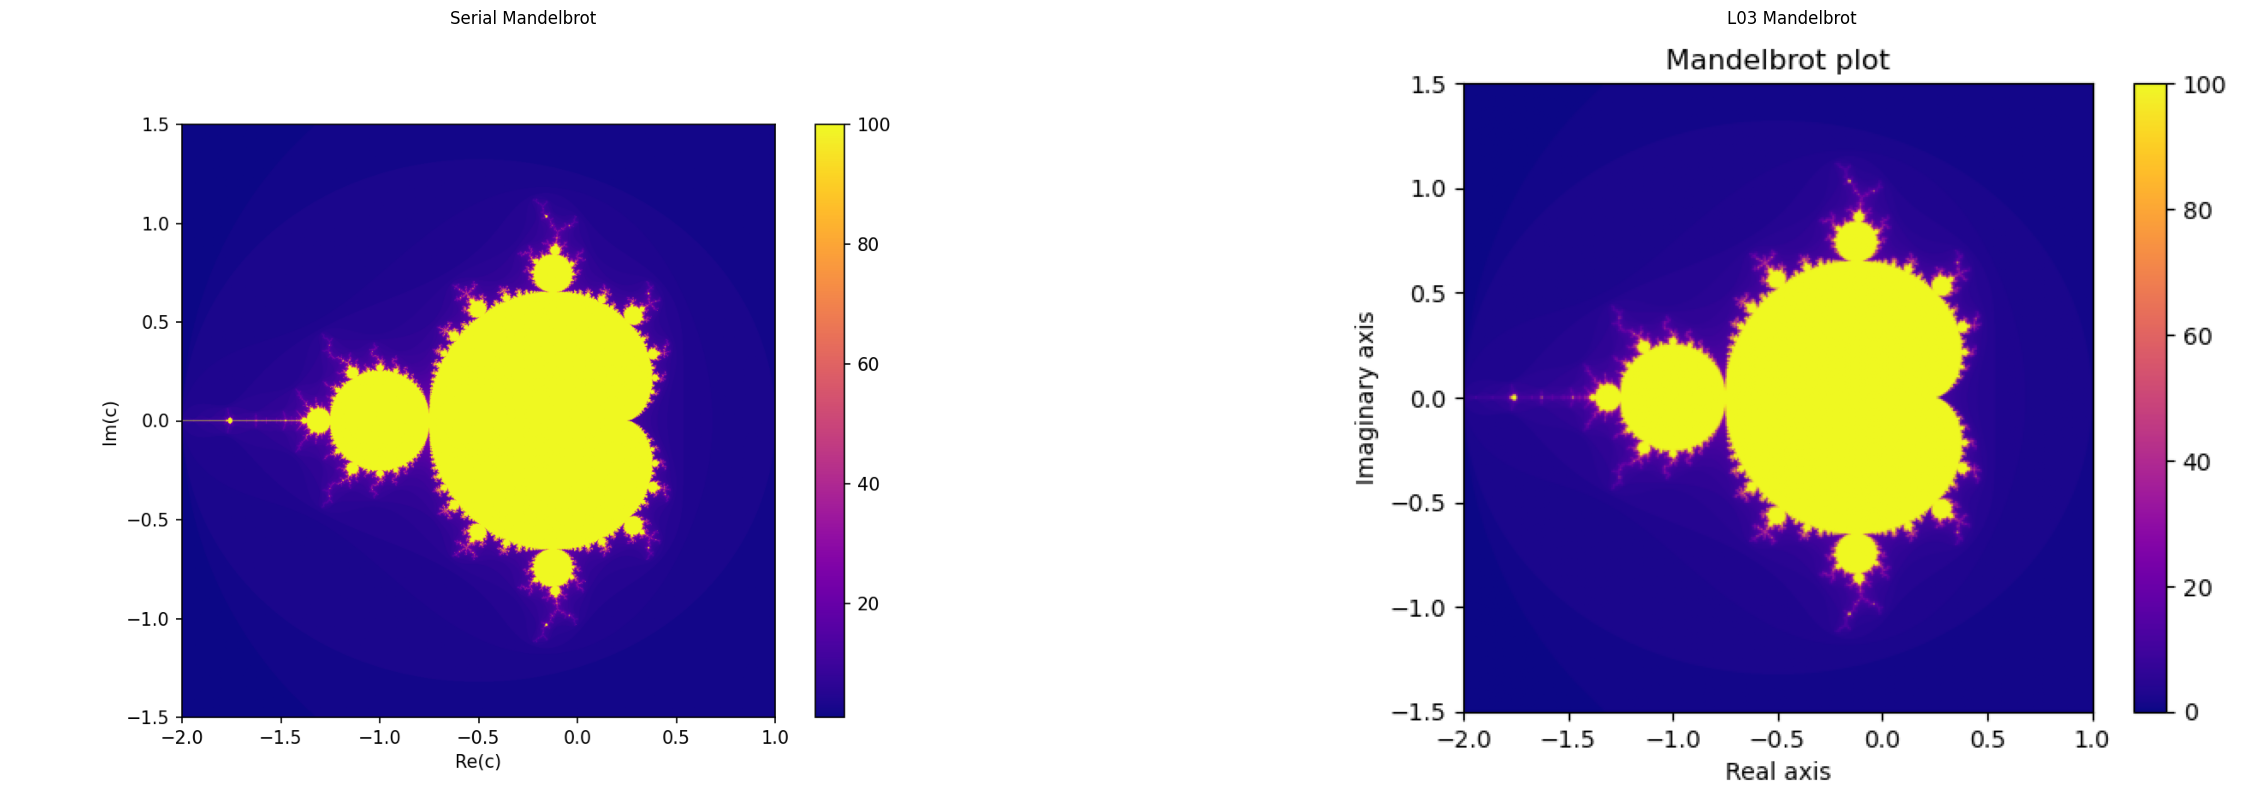

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('m1_serial_mandelbrot.png')
img2 = mpimg.imread('l03_mandelbrot.png')

fig, ax = plt.subplots( 1,2, figsize=(30,10) )
ax[0].imshow(img1)
ax[0].set_title('Serial Mandelbrot')
ax[0].axis('off')
ax[1].imshow(img2)
ax[1].set_title('L03 Mandelbrot')
ax[1].axis('off')

plt.show()

The serial mandelbrot plot and mandelbrot plot from Lecture 3 appear quite similar.

**M2 Parallel Implementation**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from multiprocessing import Pool
from pathlib import Path

import psutil
import time, os, statistics, matplotlib.pyplot as plt
import numpy as np
from numba import njit, prange

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N              = 1024 # Same width & height
x_min          = -2.0 # min point on real axis
x_max          = 1.0  # max point on real axis
y_min          = -1.5 # min point on imaginary axis
y_max          = 1.5  # max point on imaginary axis
max_iteration  = 100 # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------

@njit
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0
    
    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if ( z_real_sq + z_imag_sq ) > 4: return n
        z_imag = 2.0 * z_real*z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty( (row_end - row_start, N), dtype=np.int32)
    dx = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(x_min + column*dx, c_imag, max_iter)
    return mandelbrot_set

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter):
    """
    Calls whole grid as a single chunk
    """
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

def _worker(args):
    return mandelbrot_chunk(*args)

def mandelbrot_parallel(N, x_min, x_max, y_min, y_max, max_iter, n_workers=4):
    """
    Process mandelbrot chunks in parallel
    """
    chunk_size  = max(1, N // n_workers)
    chunks, row = [], 0
    
    while row < N:
        row_end = min(row + chunk_size, N)
        chunks.append((row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end

    with Pool(processes=n_workers) as pool:
        pool.map(_worker, chunks) # un-timed warm-up: Numba JIT in workers
        parts = pool.map(_worker, chunks)
    
    return np.vstack(parts)

if __name__ == '__main__':
    cores = psutil.cpu_count(logical=False)
    result = mandelbrot_parallel( N, x_min, x_max, y_min, y_max, max_iteration, n_workers=cores )

    fig, ax = plt.subplots( figsize=(8,6) )
    im = ax.imshow(result, extent=[x_min, x_max, y_min, y_max], cmap='plasma', origin='lower', aspect='equal')
    fig.colorbar(im, ax=ax)
    ax.set_xlabel('Re(c)')
    ax.set_ylabel('Im(c)')
    out = Path(__file__).parent / 'm2_parallel_mandelbrot.png'
    fig.savefig(out, dpi=150)
    print(f'Saved: {out}')


*Parallel Mandelbrot vs Serial Mandelbrot results*

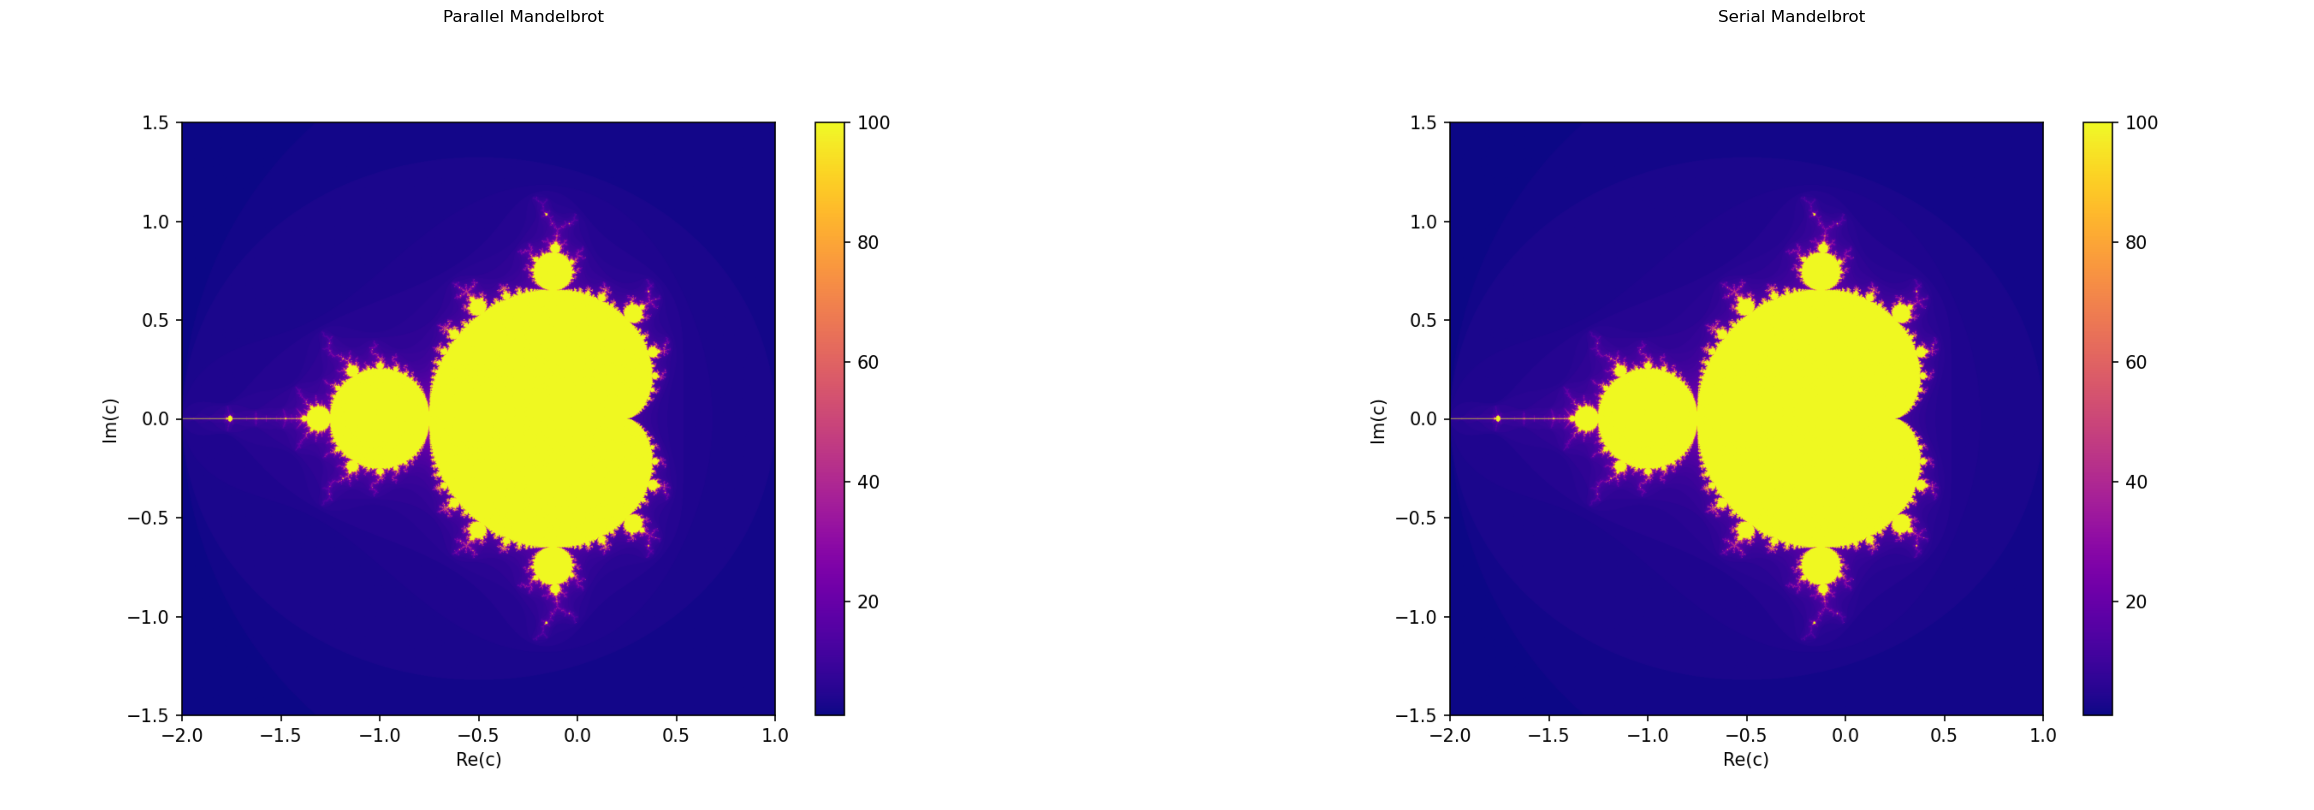

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('m2_parallel_mandelbrot.png')
img2 = mpimg.imread('m1_serial_mandelbrot.png')

fig, ax = plt.subplots( 1,2, figsize=(30,10) )
ax[0].imshow(img1)
ax[0].set_title('Parallel Mandelbrot')
ax[0].axis('off')
ax[1].imshow(img2)
ax[1].set_title('Serial Mandelbrot')
ax[1].axis('off')

plt.show()

The parallel and serial mandelbrot plots appear quite similar.

**M3 Benchmark**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from multiprocessing import Pool
from pathlib import Path

import psutil
import time, os, statistics, matplotlib.pyplot as plt
import numpy as np
from numba import njit, prange

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N              = 1024 # Same width & height
x_min          = -2.0 # min point on real axis
x_max          = 1.0  # max point on real axis
y_min          = -1.5 # min point on imaginary axis
y_max          = 1.5  # max point on imaginary axis
max_iter       = 100  # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------
@njit
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0
    
    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if ( z_real_sq + z_imag_sq ) > 4: return n
        z_imag = 2.0 * z_real*z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty( (row_end - row_start, N), dtype=np.int32)
    dx = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(x_min + column*dx, c_imag, max_iter)
    return mandelbrot_set

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter):
    """
    Calls whole grid as a single chunk
    """
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

def _worker(args):
    return mandelbrot_chunk(*args)

# ----------------------------------------------------------------------------------------------------
# Main area
# ----------------------------------------------------------------------------------------------------

if __name__ == '__main__':

    # Serial baseline (Numba already warm after M1 warm-up)
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter)
        times.append(time.perf_counter() - t0)
    t_serial = statistics.median(times)
    
    cores = psutil.cpu_count(logical=False)
    for n_workers in range(1, cores + 1):
        chunk_size = max(1, N // n_workers)
        chunks, row = [], 0
        while row < N:
            end = min(row + chunk_size, N)
            chunks.append((row, end, N, x_min, x_max, y_min, y_max, max_iter))
            row = end

        with Pool(processes=n_workers) as pool:
            pool.map(_worker, chunks) # warm-up: Numba JIT in all workers
            times = []

            for _ in range(3):
                t0 = time.perf_counter()
                np.vstack(pool.map(_worker, chunks))
                times.append(time.perf_counter() - t0)
            t_par = statistics.median(times)
            speedup = t_serial / t_par
            print(f"{n_workers:2d} workers: {t_par:.3f}s, speedup={speedup:.2f}x, eff={speedup/n_workers*100:.0f}%")


*Code output*
```
 1 workers: 0.130s, speedup=0.81x, eff=81%
 2 workers: 0.073s, speedup=1.44x, eff=72%
 3 workers: 0.091s, speedup=1.15x, eff=38%
 4 workers: 0.061s, speedup=1.72x, eff=43%
```

*Speedup Table*
| workers   | Execution time | Speedup | Efficiency |
| -------- | ------- | ------- | -------|
| 1 | 0.130s | 0.81x | 81%
| 2 | 0.073s | 1.44x | 72%
| 3 | 0.091s | 1.15x | 38%
| 4 | 0.061s | 1.72x | 43%

---

## Dask - Local Cluster

### Exercises

**Exercise 1: Overhead vs. Granularity**

In [ ]:
from multiprocessing import Pool
import random, time, os
import matplotlib.pyplot as plt
import psutil

def monte_carlo_chunk(num_samples):
    """
    Estimate pi contributions for num_samples random points.
    """
    inside = 0
    for _ in range(num_samples):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            inside += 1
    return inside

def test_granularity(total_work, chunk_size, n_proc, pool=None):
    n_chunks = total_work // chunk_size
    tasks = [chunk_size] * n_chunks
    t0 = time.perf_counter()
    if n_proc == 1 and pool is None:
        results = [monte_carlo_chunk(s) for s in tasks]
    elif pool is not None:
        results = pool.map(monte_carlo_chunk, tasks)
    return time.perf_counter() - t0, 4 * sum(results) / total_work

if __name__ == '__main__':
    results = []
    
    total_work = 1_000_000
    # n_proc = os.cpu_count() // 2
    n_proc = psutil.cpu_count(logical=False)
    
    chunk_sizes = [10, 100, 1_000, 10_000, 100_000, 1_000_000]
    print(f"{'L':>12} | {'serial(s)':>12} | {'parallel(s)':>12} | {'pi'}")

    with Pool(processes=n_proc) as pool:
        for L in chunk_sizes:
            t_ser, _ = test_granularity(total_work, L, n_proc=1)
            t_par, pi = test_granularity(total_work, L, n_proc=n_proc, pool=pool)
            print(f"{L:12d} | {t_ser:12.4f} | {t_par:12.4f} | pi={pi:.4f}")
            
            new_entry = {
                'L':L,
                't_ser':t_ser,
                't_par':t_par,
                'pi':pi,
            }
            results.append( new_entry )
        
    # Plotting
    chunk_sizes    = [ r['L'] for r in results ]
    serial_times   = [ r['t_ser'] for r in results ]
    parallel_times = [ r['t_par'] for r in results ]
    
    plt.figure()
    plt.plot( chunk_sizes, serial_times, marker='o' )
    plt.xscale('log')
    plt.xlabel('Chunk size L')
    plt.ylabel('t serial time (s)')
    plt.title('Chunk size vs serial time')
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot( chunk_sizes, parallel_times, marker='o' )
    plt.xscale('log')
    plt.xlabel('Chunk size L')
    plt.ylabel('t parallel time (s)')
    plt.title('Chunk size vs Parallel time')
    plt.grid()
    plt.show()


```
           L |    serial(s) |  parallel(s) | pi
          10 |       0.3843 |       0.6286 | pi=3.1448
         100 |       0.1950 |       0.0687 | pi=3.1444
        1000 |       0.2098 |       0.0724 | pi=3.1418
       10000 |       0.2160 |       0.0738 | pi=3.1445
      100000 |       0.2187 |       0.0782 | pi=3.1415
     1000000 |       0.2181 |       0.2096 | pi=3.1429
```

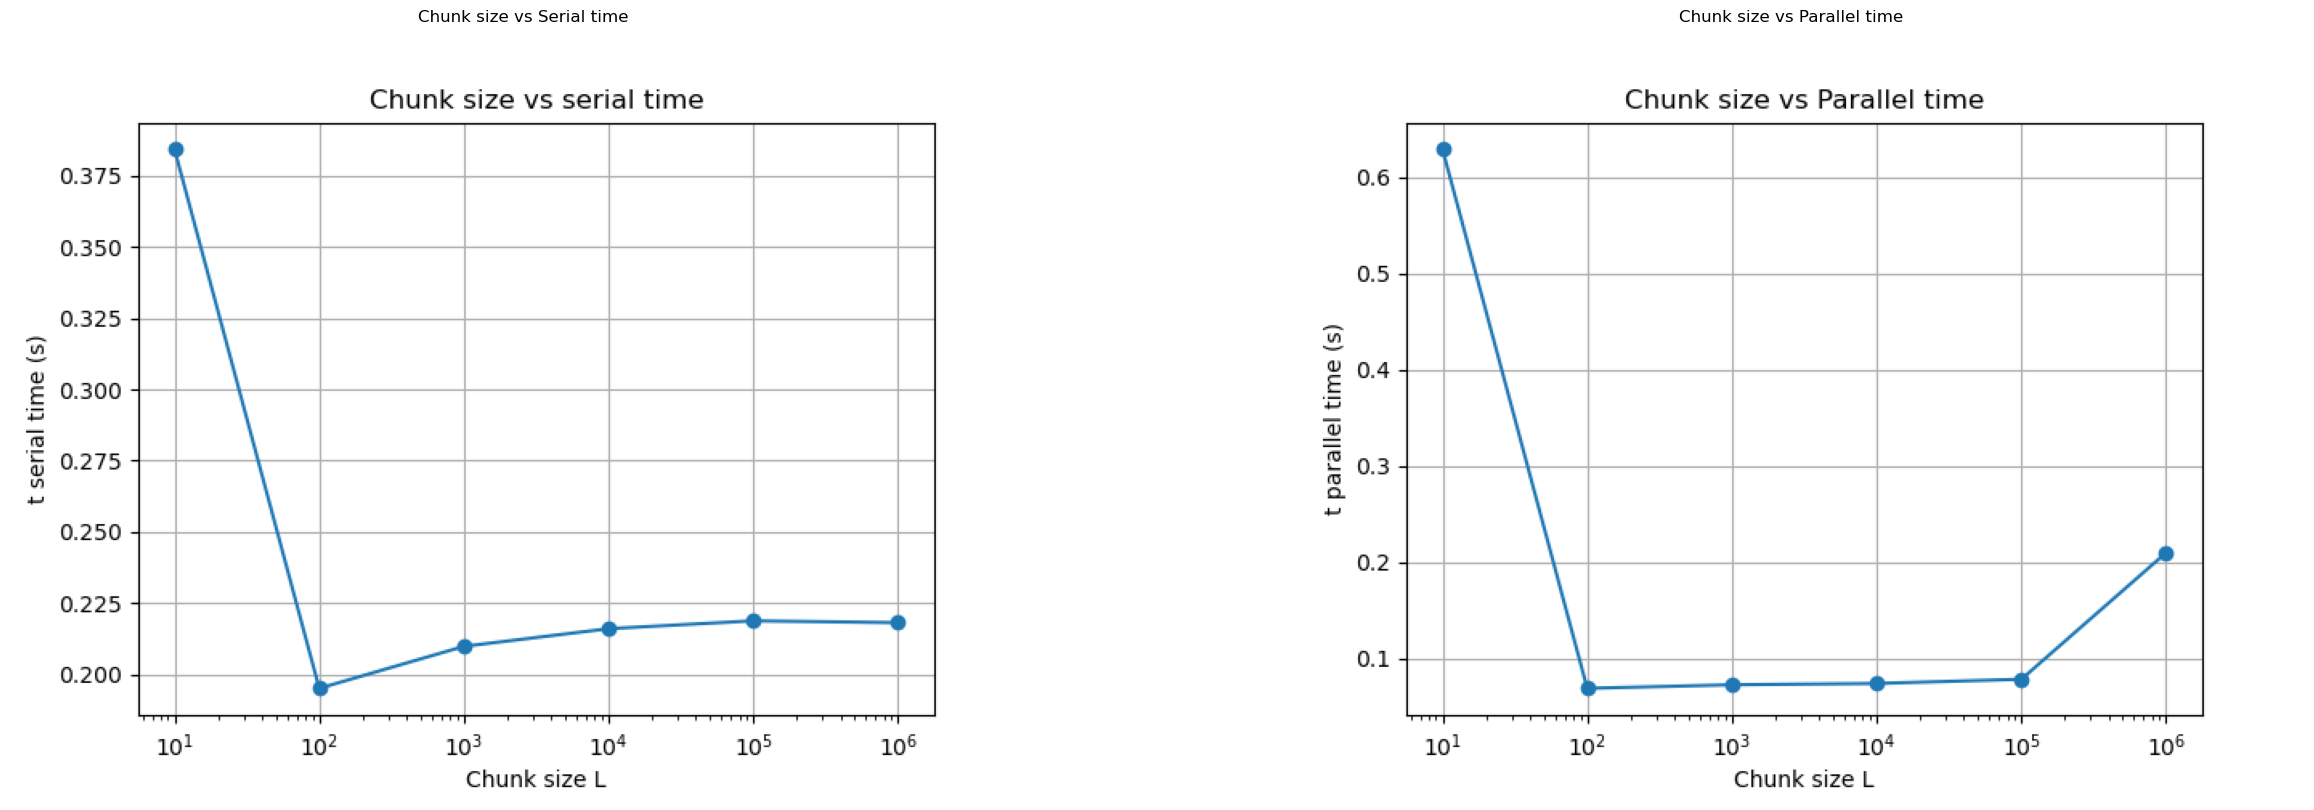

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('ex1_chunk_sz_vs_serial_time.png')
img2 = mpimg.imread('ex1_chunk_sz_vs_parallel_time.png')

fig, ax = plt.subplots( 1,2, figsize=(30,10) )
ax[0].imshow(img1)
ax[0].set_title('Chunk size vs Serial time')
ax[0].axis('off')
ax[1].imshow(img2)
ax[1].set_title('Chunk size vs Parallel time')
ax[1].axis('off')

plt.show()

**Where is the optimal L for your machine?**

Based on the results, it seems that the lowest elapsed time for serial is for 100 chunks and for parallel the best chunk size is also 100.

**Exercise 2: Serial pipeline → parallel map**

In [ ]:
import random, time
from functools import reduce
from multiprocessing import Pool

N = 1_000_000
data = [random.randint(10, 100) for _ in range(N)]

def subtract_seven(x):
    return x - 7

if __name__ == '__main__':

    # Part 1
    t0 = time.perf_counter()
    result_ser = reduce(lambda a, b: a + b,
                        filter
                        (lambda x: x % 2 == 1,
                            map(subtract_seven, data)))
    t_serial = time.perf_counter() - t0

    # Part 2 - Move start of time after Pool() to exclude time it takes to spawn processes.
    with Pool() as pool:
        t0 = time.perf_counter()
        mapped = pool.map(subtract_seven, data)
        result_par = reduce(lambda a, b: a + b,
                            filter(lambda x: x % 2 == 1, mapped))
        t_parallel = time.perf_counter() - t0

    print(f"Serial:{t_serial:.4f}s result={result_ser}")
    print(f"Parallel:{t_parallel:.4f}s result={result_par}")
    print(f"Speedup:{t_serial/ t_parallel:.2f}x")


**Part 1 Serial**

Output:
```
Serial:0.1861s result=24248792
```

**Part 2 Parallel**
* Before running — predict: will Pool.map() be faster? Why or why not? *It might not be faster, as the amount of work is so small it might take even less time than the multiprocessing overhead.*
* Replace map(subtract seven, data) with pool.map(subtract seven, data)
* Time both versions and compare

Output:
```
Serial:0.1861s result=24248792
Parallel:1.4088s result=24248792
Speedup:0.13x
```

**After running**
* Was your prediction correct? *The results indicate that the elapsed time using the parallel approach is slower in this case. This aligns with my prediction.*
* How does this compare to the overhead curve you saw in E1? *Similar to what we saw in exercise 1, parallel execution introduces some overhead. When the compute-task is very small, the overhead from creating tasks and doing IPC could take up the majority of the time and thereby cause the parallel version to perform worse. This can e.g. Be seen on the parallel curve from exercise 1. The smallest chunk size results in a much higher execution time. It is even much higher than the worst serial test*

### Milestones

**Milestone 1 - Chunked Mandelbrot**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from multiprocessing import Pool
from pathlib import Path

import psutil
import time, os, statistics, matplotlib.pyplot as plt
import numpy as np
from numba import njit, prange

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N              = 1024 # Same width & height
x_min          = -2.0 # min point on real axis
x_max          = 1.0  # max point on real axis
y_min          = -1.5 # min point on imaginary axis
y_max          = 1.5  # max point on imaginary axis
max_iteration  = 100 # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------

@njit(cache=True) # avoid that every new worker process re-compiles the numba function from scratch.
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0
    
    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if ( z_real_sq + z_imag_sq ) > 4: return n
        z_imag = 2.0 * z_real*z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty( (row_end - row_start, N), dtype=np.int32)
    dx = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(x_min + column*dx, c_imag, max_iter)
    return mandelbrot_set

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter):
    """
    Calls whole grid as a single chunk
    """
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

def _worker(args):
    return mandelbrot_chunk(*args)

def mandelbrot_parallel(N, x_min, x_max, y_min, y_max, max_iter, n_workers=4, n_chunks=None, pool=None):
    """
    Process mandelbrot chunks in parallel
    """
    if n_chunks is None:
        n_chunks = n_workers
    # print(f'n chunks: [{n_chunks}]')

    chunk_size  = max(1, N // n_chunks)
    chunks, row = [], 0
    
    while row < N:
        row_end = min(row + chunk_size, N)
        chunks.append((row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end

    if pool is not None:
        return np.vstack( pool.map(_worker,chunks) )
    
    tiny = [ (0,8,8,x_min,x_max,y_min,y_max,max_iter) ]

    with Pool(processes=n_workers) as p:
        p.map(_worker, tiny) # warm-up -> load JIT cache in workers
        parts = p.map(_worker, chunks)
    return np.vstack(parts)

def benchmark ( func , * args , n_runs =3) -> tuple:
    """ Time func , return median of n_runs . """
    times = []
    for _ in range ( n_runs ):
        t0 = time . perf_counter ()
        result = func (* args )
        times . append ( time . perf_counter () - t0 )
    
    median_t = statistics . median ( times )
    
    print (f" Median : { median_t :.4f}s "
        f"( min ={ min( times ):.4f}, max ={ max( times ):.4f})")
    
    return median_t, result

if __name__ == '__main__':
    cores = psutil.cpu_count(logical=False)
    
    t, M = benchmark(mandelbrot_parallel, N, x_min, x_max, y_min, y_max, max_iteration, cores)

    fig, ax = plt.subplots( figsize=(8,6) )
    im = ax.imshow(M, extent=[x_min, x_max, y_min, y_max], cmap='plasma', origin='lower', aspect='equal')
    fig.colorbar(im, ax=ax)
    ax.set_xlabel('Re(c)')
    ax.set_ylabel('Im(c)')
    out = Path(__file__).parent / 'chunked_mandelbrot_m1_4_parallel_mandelbrot.png'
    fig.savefig(out, dpi=150)
    print(f'Saved: {out}')

    t, M = benchmark(mandelbrot_parallel, N, x_min, x_max, y_min, y_max, max_iteration, cores, cores*4)

    fig, ax = plt.subplots( figsize=(8,6) )
    im = ax.imshow(M, extent=[x_min, x_max, y_min, y_max], cmap='plasma', origin='lower', aspect='equal')
    fig.colorbar(im, ax=ax)
    ax.set_xlabel('Re(c)')
    ax.set_ylabel('Im(c)')
    out = Path(__file__).parent / 'chunked_mandelbrot_m1_16_parallel_mandelbrot.png'
    fig.savefig(out, dpi=150)
    print(f'Saved: {out}')

**Chunked Mandelbrot vs Serial Mandelbrot from L04**

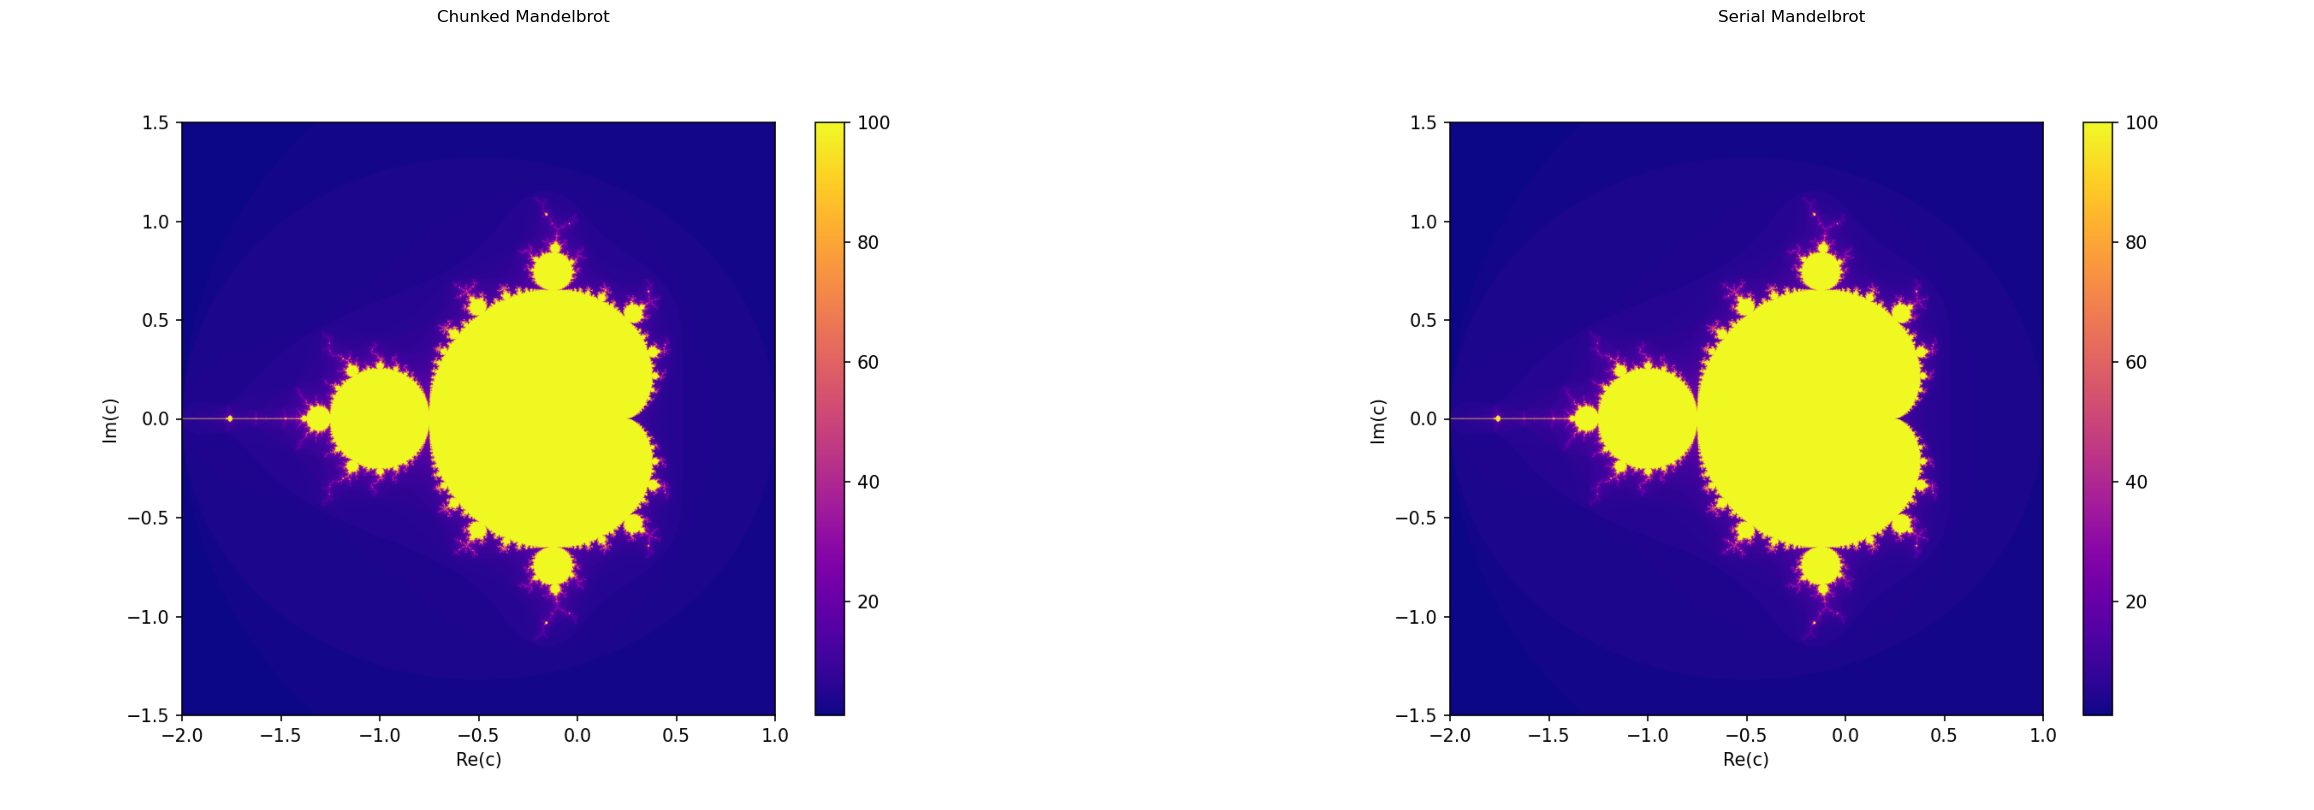

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('chunked_mandelbrot_m1_4_parallel_mandelbrot.png')
img2 = mpimg.imread('m1_serial_mandelbrot.png')

fig, ax = plt.subplots( 1,2, figsize=(30,10) )
ax[0].imshow(img1)
ax[0].set_title('Chunked Mandelbrot')
ax[0].axis('off')
ax[1].imshow(img2)
ax[1].set_title('Serial Mandelbrot')
ax[1].axis('off')

plt.show()

The chunked Mandelbrot plot appears very similar to the serial mandelbrot plot.

*Re-run the L04 worker-count benchmark with n chunks = 4 × n workers; note any change?*

```
Median : 2.4429s ( min =2.1204, max =2.5796)
Median : 2.1002s ( min =2.0992, max =2.1709)
```

No major changes were observed. The average elapsed time based on three benchmarks indicates that using 4 or 16 chunks results in elapsed times that are some hundreds of milliseconds apart.

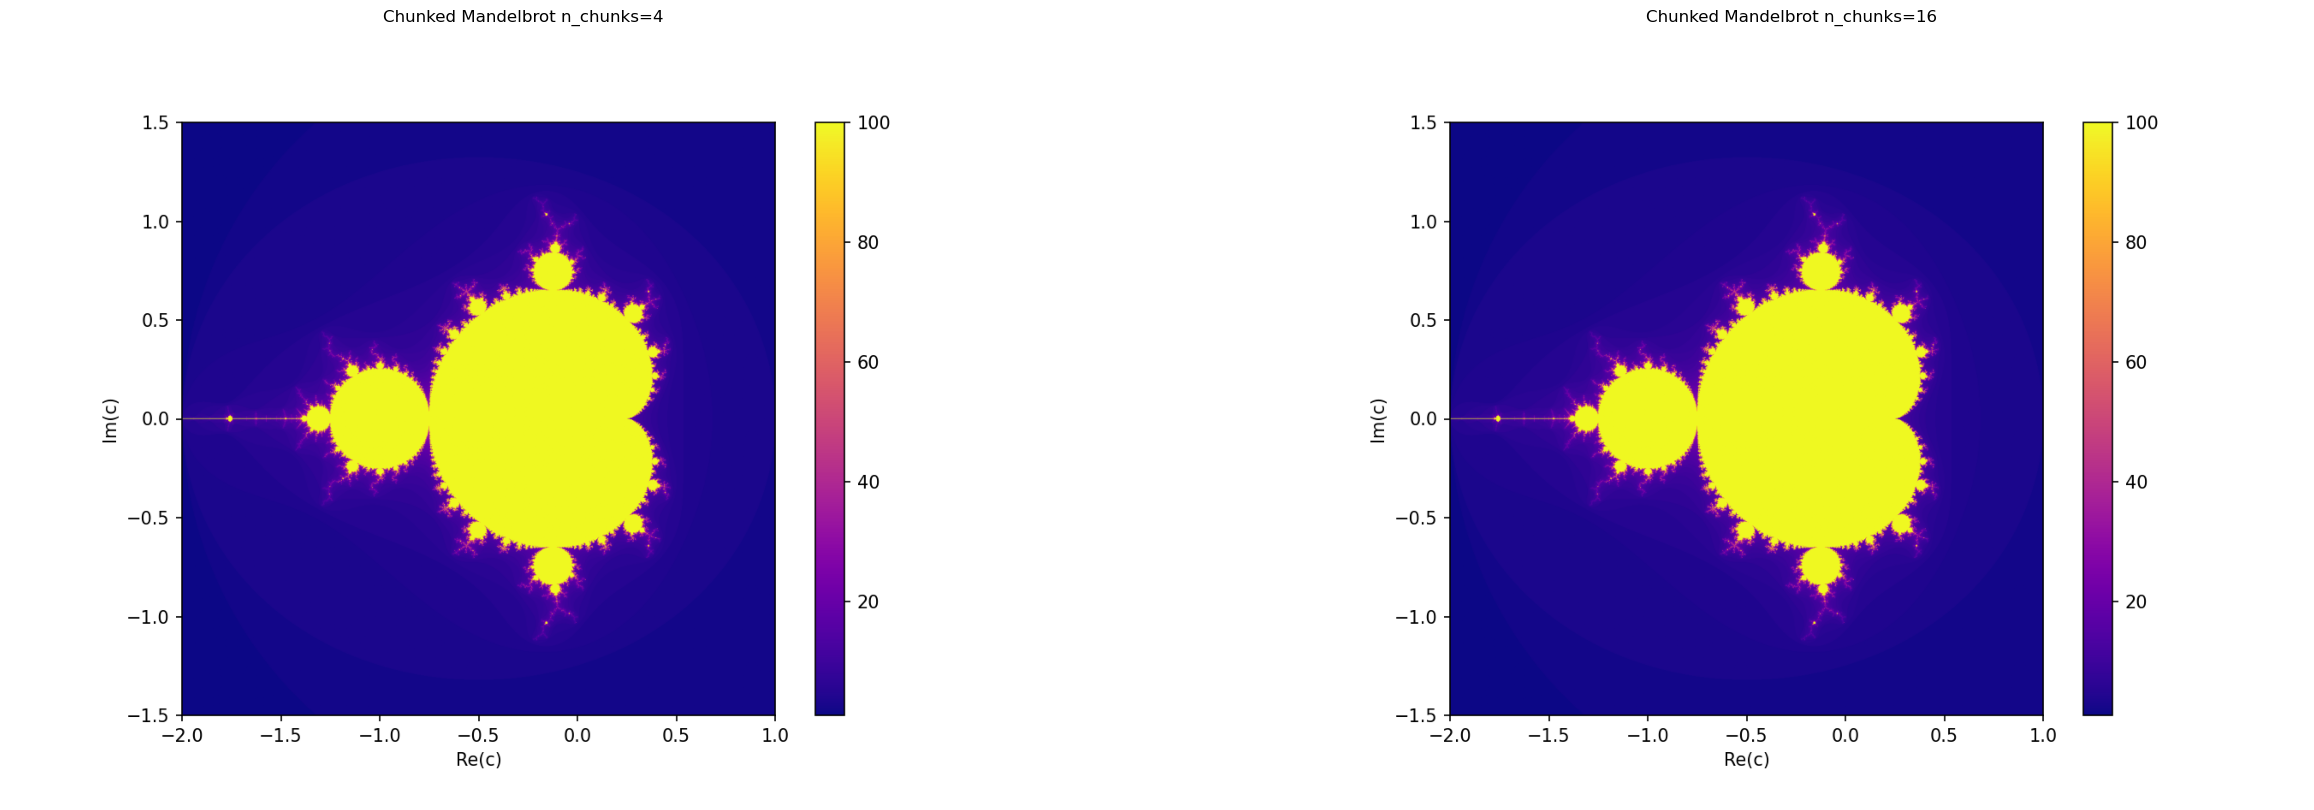

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('chunked_mandelbrot_m1_4_parallel_mandelbrot.png')
img2 = mpimg.imread('chunked_mandelbrot_m1_16_parallel_mandelbrot.png')

fig, ax = plt.subplots( 1,2, figsize=(30,10) )
ax[0].imshow(img1)
ax[0].set_title('Chunked Mandelbrot n_chunks=4')
ax[0].axis('off')
ax[1].imshow(img2)
ax[1].set_title('Chunked Mandelbrot n_chunks=16')
ax[1].axis('off')

plt.show()

**Milestone 2 - Optimal Chunk Size**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from multiprocessing import Pool
from pathlib import Path

import time, os, statistics, matplotlib.pyplot as plt
import numpy as np
from numba import njit, prange

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N              = 1024 # Same width & height
x_min          = -2.0 # min point on real axis
x_max          = 1.0  # max point on real axis
y_min          = -1.5 # min point on imaginary axis
y_max          = 1.5  # max point on imaginary axis
max_iteration  = 100 # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------

@njit(cache=True) # avoid that every new worker process re-compiles the numba function from scratch. Instead, new workers can load from generated __pycache__ folder.
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0
    
    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if ( z_real_sq + z_imag_sq ) > 4: return n
        z_imag = 2.0 * z_real*z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty( (row_end - row_start, N), dtype=np.int32)
    dx = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(x_min + column*dx, c_imag, max_iter)
    return mandelbrot_set

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter):
    """
    Calls whole grid as a single chunk
    """
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

def _worker(args):
    return mandelbrot_chunk(*args)

def mandelbrot_parallel(N, x_min, x_max, y_min, y_max, max_iter, n_workers=4, n_chunks=None, pool=None):
    """
    Process mandelbrot chunks in parallel
    """
    if n_chunks is None:
        print('No n_chunks specified...')
        return
    
    chunk_size  = max(1, N // n_chunks)
    chunks, row = [], 0
    
    while row < N:
        row_end = min(row + chunk_size, N)
        chunks.append((row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end

    if pool is not None:
        return np.vstack( pool.map(_worker,chunks) )

def benchmark ( func , * args , n_runs =3) -> tuple:
    """ Time func , return median of n_runs . """
    times = []
    for _ in range ( n_runs ):
        t0 = time . perf_counter ()
        result = func (* args )
        times . append ( time . perf_counter () - t0 )
    
    median_t = statistics.median( times )
    return median_t, result

if __name__ == '__main__':

    # Measure serial wall time
    T1, _ = benchmark(mandelbrot_serial, N, x_min, x_max, y_min, y_max, max_iteration, n_runs=3)
    print(f'T1 (Baseline serial wall time): {T1:.3f}s')

    optimum_n_workers = 4
    n_chunks          = [ 1, 2, 4, 8, 16 ]
    results           = []

    with Pool( optimum_n_workers ) as pool:
        # warm-up -> load JIT cache in workers
        tiny = [ (0,8,8,x_min,x_max,y_min,y_max,max_iteration) ]
        pool.map(_worker, tiny) # warm-up -> load JIT cache in workers

        # Sweep number of chunks
        for n_chunk in n_chunks:
            t, _ = benchmark(mandelbrot_parallel, N, x_min, x_max, y_min, y_max, max_iteration, optimum_n_workers, n_chunk * optimum_n_workers, pool)

            new_results = {
                'n_workers': optimum_n_workers,
                'n_chunks' : n_chunk * optimum_n_workers,
                'time'     : t,
                'lif'      : (optimum_n_workers * t / T1) - 1 # Load imbalance factor
            }

            results.append( new_results )

    n_workers = [ r['n_workers'] for r in results ]
    n_chunks  = [ r['n_chunks'] for r in results ]
    times     = [ r['time'] for r in results ]
    lifs      = [ r['lif'] for r in results ]

    # Display results
    for i in range( len(results) ):
        speedup = T1 / times[i]
        print(f'Workers: {n_workers[i]}, n_chunks: {n_chunks[i]}, time: {times[i]:.3f}s, speedup: {speedup:.3f}, lif: {lifs[i]:.3f}')


*Output*

Based on L04, the optimal amount of cores was 4, so this experiment is based on using 4 cores.

```
T1 (Baseline serial wall time): 0.078s
Workers: 4, n_chunks: 4, time: 0.048s, speedup: 1.631, lif: 1.453
Workers: 4, n_chunks: 8, time: 0.033s, speedup: 2.356, lif: 0.698
Workers: 4, n_chunks: 16, time: 0.030s, speedup: 2.593, lif: 0.543
Workers: 4, n_chunks: 32, time: 0.029s, speedup: 2.647, lif: 0.511
Workers: 4, n_chunks: 64, time: 0.028s, speedup: 2.757, lif: 0.451
```

The biggest speedup seems to be at 64 chunks and 4 workers.
In this case, the ideal chunk size is actually bigger than the typical sweet spot of 4-8 times the number of workers.

**Milestone 3 - Comprehensive Analysis**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from multiprocessing import Pool
from pathlib import Path

import time, os, statistics, matplotlib.pyplot as plt
import numpy as np
from numba import njit, prange
import os
import matplotlib.pyplot as plt
import psutil

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N              = 1024 # Same width & height
x_min          = -2.0 # min point on real axis
x_max          = 1.0  # max point on real axis
y_min          = -1.5 # min point on imaginary axis
y_max          = 1.5  # max point on imaginary axis
max_iteration  = 100 # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------

@njit(cache=True) # avoid that every new worker process re-compiles the numba function from scratch. Instead, new workers can load from generated __pycache__ folder.
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0
    
    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if ( z_real_sq + z_imag_sq ) > 4: return n
        z_imag = 2.0 * z_real*z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty( (row_end - row_start, N), dtype=np.int32)
    dx = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(x_min + column*dx, c_imag, max_iter)
    return mandelbrot_set

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter):
    """
    Calls whole grid as a single chunk
    """
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

def _worker(args):
    return mandelbrot_chunk(*args)

def mandelbrot_parallel(N, x_min, x_max, y_min, y_max, max_iter, n_workers=4, n_chunks=None, pool=None):
    """
    Process mandelbrot chunks in parallel
    """
    if n_chunks is None:
        print('No n_chunks specified...')
        return
    
    chunk_size  = max(1, N // n_chunks)
    chunks, row = [], 0
    
    while row < N:
        row_end = min(row + chunk_size, N)
        chunks.append((row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end

    if pool is not None:
        return np.vstack( pool.map(_worker,chunks) )

def benchmark ( func , * args , n_runs =3) -> tuple:
    """ Time func , return median of n_runs . """
    times = []
    for _ in range ( n_runs ):
        t0 = time . perf_counter ()
        result = func (* args )
        times . append ( time . perf_counter () - t0 )
    
    median_t = statistics.median( times )
    return median_t, result

if __name__ == '__main__':

    # Measure serial wall time
    T1, _ = benchmark(mandelbrot_serial, N, x_min, x_max, y_min, y_max, max_iteration, n_runs=3)
    print(f'T1 (Baseline serial wall time): {T1:.3f}s')

    optimum_n_workers = 4
    n_chunks          = [ 1, 2, 4, 8, 16 ]
    results           = []

    with Pool( processes=optimum_n_workers ) as pool:
        # warm-up -> load JIT cache in workers
        tiny = [ (0,8,8,x_min,x_max,y_min,y_max,max_iteration) ]
        pool.map(_worker, tiny) # warm-up -> load JIT cache in workers

        # Sweep number of chunks
        for n_chunk in n_chunks:
            t, M = benchmark(mandelbrot_parallel, N, x_min, x_max, y_min, y_max, max_iteration, optimum_n_workers, n_chunk * optimum_n_workers, pool)

            new_results = {
                'n_workers': optimum_n_workers,
                'n_chunks' : n_chunk * optimum_n_workers,
                'time'     : t,
                'lif'      : (optimum_n_workers * t / T1) - 1 # Load imbalance factor
            }
            results.append( new_results )

    # Display results
    n_workers = [ r['n_workers'] for r in results ]
    n_chunks  = [ r['n_chunks'] for r in results ]
    times     = [ r['time'] for r in results ]
    lifs      = [ r['lif'] for r in results ]
    for i in range( len(results) ):
        speedup = T1 / times[i]
        print(f'Workers: {n_workers[i]}, n_chunks: {n_chunks[i]}, time: {times[i]:.3f}s, speedup: {speedup:.3f}, lif: {lifs[i]:.3f}')
    
    # ----- Sweep number of workers...
    print('-'*100)
    results = []
    optimum_n_chunks = 64
    cores = psutil.cpu_count(logical=False)
    for n_workers in range(1, cores + 1):
        with Pool( processes=n_workers ) as pool:
            # warm-up -> load JIT cache in workers
            tiny = [ (0,8,8,x_min,x_max,y_min,y_max,max_iteration) ]
            pool.map(_worker, tiny) # warm-up -> load JIT cache in workers

            t, M = benchmark(mandelbrot_parallel, N, x_min, x_max, y_min, y_max, max_iteration, n_workers, optimum_n_chunks, pool)
            new_results = {
                'n_workers': n_workers,
                'n_chunks' : optimum_n_chunks,
                'time'     : t,
                'lif'      : (n_workers * t / T1) - 1 # Load imbalance factor
            }
            results.append( new_results )
    
    # Plot actual vs ideal speedups
    ideal_speedup = [ r['n_workers'] for r in results ]
    actual_speeup = [ T1 / r['time'] for r in results ]

    fig, ax = plt.subplots()
    ax.plot( [r['n_workers'] for r in results], actual_speeup, 'o-', label='Actual' )
    ax.plot( [r['n_workers'] for r in results], ideal_speedup, '--', label='Ideal' )
    ax.set_xlabel('Number of workers')
    ax.set_ylabel('Speedup')
    ax.set_title('Actual vs Ideal Speedup')
    ax.grid()
    ax.legend()

    out = Path(__file__).parent / 'comprehensive_analysis_m3.png'
    fig.savefig(out, dpi=150)
    print(f'Saved: {out}')

*1. Speedup table*

**Benchmark Table (based on results from MP1 report and chunked parallel Mandelbrot with optimal chunk size)**
| Version   | Time | Speedup |
| -------- | ------- | ------- |
| Naive    | 10.260s | 1x      |
| Numpy    | 0.870s  | 11.8x   |
| Numba    | 0.075s  | 136.9x  |
| Parallel | 0.028s  | 366.4x  |

*2. Speedup vs. core count*

Actual vs Ideal (linear)



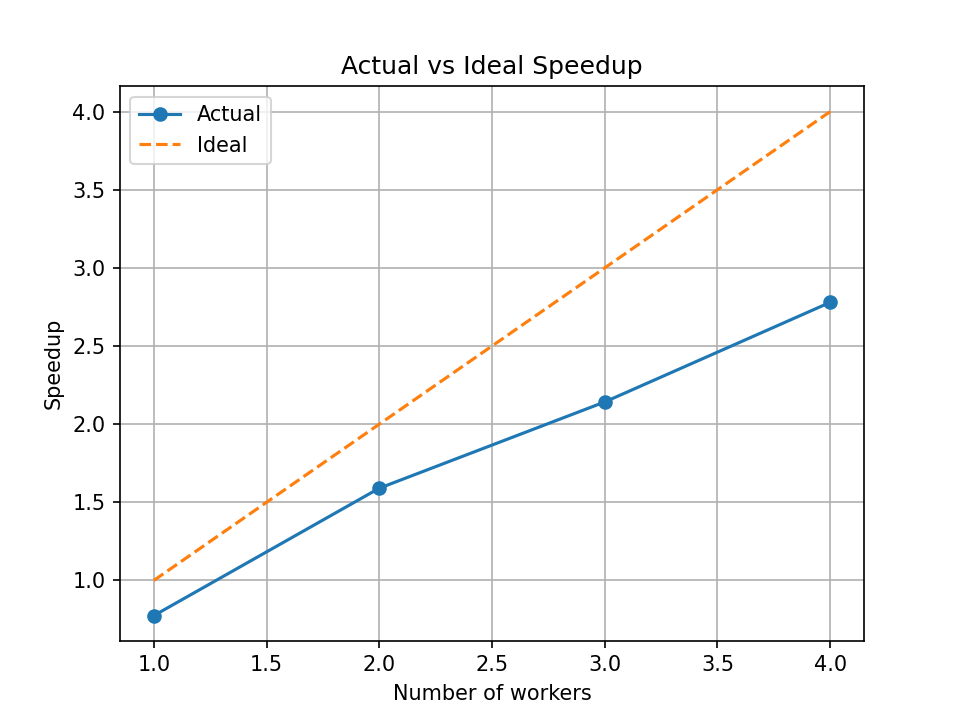

In [5]:
from IPython.display import Image, display
display(Image(filename="comprehensive_analysis_m3.png", width=600))

Back-solve implied s:
* Speedup here is based on optimal chunk size with parallel Mandelbrot vs serial Numba baseline.
* Speedup compared to serial Numba baseline of 0.078s, as we got from milestone 2 optimal chunk size, is 0.078/0.028=2.757

$$
s = \frac{ \frac{1}{2.757} - \frac{1}{4} }{ 1 - \frac{1}{4} } = 0,1503
$$

This means that the program has an effective serial fraction of about 15%.

Is your s smaller than your L04 result?
* From L04 milestone 3, I measured execution time to be 0.061s for 4 workers without configuring the chunk size.
* Speedup compared to serial Numba baseline of 0.078s, as we got from milestone 2 optimal chunk size, is 0.078/0.061=1.278

$$
s = \frac{ \frac{1}{1.278} - \frac{1}{4} }{ 1 - \frac{1}{4} } = 0,7099
$$

This means that the program has an effective serial fraction of about 70%. A much higher portion than the chunked Mandelbrot version.
This also suggests that the chunked Mandelbrot version implementation has better load balance.

*Brief recommendation*

* What settings give the best time? **

* Is parallelisation worth it on your
hardware?

* Compare speedup and LIF to your serial Numba baseline

* Write 2–3 sentences in your performance notebook

*Based on the experiements, the best settings was obtained using 4 cores and a chunk size of 64. By comparison to the serial Numba baseline, the speedup was at 2.757 with a low load imbalance factor LIF at 0.451 and the serial fraction at about 15% This indicates a good load balanace and suggests that only a small amount of the program is sequential. All in all, parallelization definitely results in bigger speedup. This is clearly evident based on the previously indicated speedup table.*

---

## Dask - AAU Strato HPC cluster

### Code

### Milestones

**Milestone 1:**